<h1>We're going to make a recycling model that identifies the type of trash in the image</h1>

<h3>We're going to start with importing every library we'll need</h3>

In [92]:

import numpy as np 
import pandas as pd 
import keras
import cv2
import tensorflow as tf
import os


import matplotlib.pyplot as plt 
%matplotlib inline

from keras.models import Sequential
from keras.layers import Dense , Activation, Dropout
from keras.optimizers import Adam ,RMSprop
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# Trying to avoid unecessary warnings
pd.options.mode.chained_assignment = None
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


<h3>Now we'll import our data and make an x (input) and y (output) list</h3>
Note: Trash folder was removed and folders biological, metal, and batteries had the standardized256 versions mixed in with the originals.

In [93]:
trainDataPath = 'data/dataMixStandardizWithIt'
trashTypes = os.listdir(trainDataPath)

xData = []
yData = []

print(trashTypes)

['cardboard', 'glass', 'shoes', 'biological', 'plastic', 'paper', 'clothes', 'metal', 'battery']


In [94]:
resizeX = 32
resizeY = 32
count = 0
listSection = [1]
for i in (range(len(trashTypes)-1)):
    listSection.append(0)



# --------------------- The structure will be that each x will contain all the image data
# --------------------- and each corrosponding y will be the label of x

for i in (trashTypes):
    print("Adding " + i)
        
    # Creates a list of every item in the differing recycling category
    pathForiPath = os.listdir(trainDataPath+"/"+i)
    for j in pathForiPath:

        # Creates the individual path to each item that will be analyzed
        pathToTrashItem = (trainDataPath+"/"+i+"/"+j)
        # Converts the image to a list of individual (blue, green, red) lists per pixels
        bgrImg = cv2.imread(pathToTrashItem)
        bgrImg = cv2.resize(bgrImg, (resizeX,resizeY))
        rgbImg = cv2.cvtColor(bgrImg, cv2.COLOR_BGR2RGB)
        count = count+1
        xData.append(rgbImg.copy())
        yData.append(listSection.copy())
    # print(listSection)
    listSection.pop()
    listSection.insert(0,0)
print("Count is {}".format(str(count)))

Adding cardboard
Adding glass
Adding shoes
Adding biological
Adding plastic
Adding paper
Adding clothes
Adding metal
Adding battery
Count is 14147


<h1>Now we split the data into test and train sets</h1>

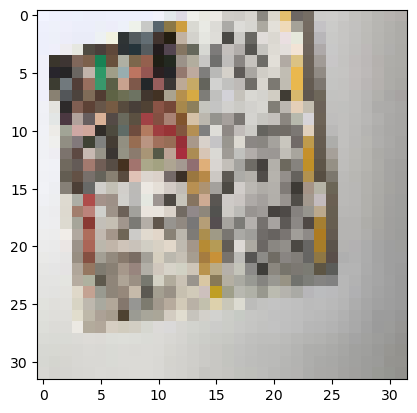

In [95]:
xTrain, xTest, yTrain, yTest = train_test_split(xData, yData, test_size=0.20, random_state=43)

# Showing augmented image
plt.imshow(xTrain[2])
plt.show()

<h1>Here image augmentation is performed</h1>
Adding rotated duplicates of our images to our training set

In [96]:
for i in range(len(xTrain)):
    k = len(xTrain)-i-1
    rgbImg = xTrain[k]
    for k in range(3):
        rgbImg = cv2.rotate(rgbImg, cv2.ROTATE_90_CLOCKWISE).copy()
        xTrain.append(rgbImg.copy())
        yTrain.append(yTrain[k].copy())
        count = count+1


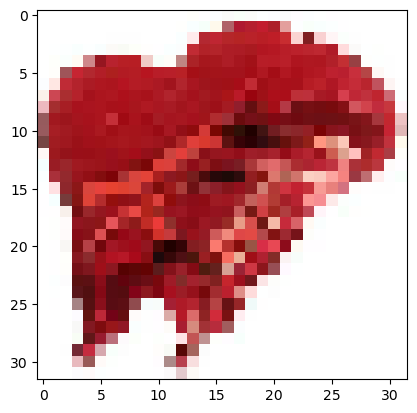

In [97]:
plt.imshow(xTrain[len(xTrain)-7])
plt.show()

In [98]:
remix = np.random.permutation(len(xTrain))
xTrain = np.resize(xTrain, [len(xTrain), resizeX,resizeY,3]).astype('float32')[remix] / 255
xTest = np.resize(xTest, [len(xTest), resizeX,resizeY,3]).astype('float32') / 255

yTrain = np.array(yTrain)[remix]
yTest = np.array(yTest)


print(len(yTest))

2830


<h3>Now to create the model</h3>

In [107]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.layers import Resizing
from keras.applications.resnet50 import ResNet50

batch_size = 16
classifier = Sequential(name = "Recycle Bot")
mobileNet = tf.keras.applications.MobileNetV2(weights="imagenet")
mobileNet.trainable = False
model = models.Sequential()
# Have to resize for MobileNetV2
model.add(Resizing(224, 224, interpolation='bilinear'))
model.add(mobileNet)
model.add(layers.Dense(len(trashTypes), activation='softmax'))
model.compile(optimizer='adam', 
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
classifier = model
trainAcc = None
trainLoss = None
testLoss = []
testAcc = []
testX = 0

In [108]:
# Setup to record each epoch's unseen data accuracy score
for i in range(50):
    print("Epoch: "+str(i+1))
    current = classifier.fit(xTrain, yTrain, epochs=1, batch_size=batch_size)
    if (trainAcc is not None) and (trainAcc is not current.history['accuracy']):
        trainAcc = trainAcc+current.history['accuracy']
        trainLoss = trainLoss+current.history['loss']

    else:
        trainAcc = current.history['accuracy']
        trainLoss = current.history['loss']

    testL, testA = classifier.evaluate(xTest, yTest, batch_size=batch_size)
    testAcc.append(testA)
    testLoss.append(testL)

Epoch: 1
2830/2830 ━━━━━━━━━━━━━━━━━━━━ 212s 74ms/step - accuracy: 0.5234 - loss: 1.3466
177/177 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.1339 - loss: 2.2510
Epoch: 2
2830/2830 ━━━━━━━━━━━━━━━━━━━━ 211s 75ms/step - accuracy: 0.5471 - loss: 1.0722
177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.2580 - loss: 1.9711
Epoch: 3
2830/2830 ━━━━━━━━━━━━━━━━━━━━ 211s 75ms/step - accuracy: 0.5802 - loss: 0.9872
177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.3806 - loss: 1.8021
Epoch: 4
2830/2830 ━━━━━━━━━━━━━━━━━━━━ 211s 75ms/step - accuracy: 0.6037 - loss: 0.9392
177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.4339 - loss: 1.6992
Epoch: 5
2830/2830 ━━━━━━━━━━━━━━━━━━━━ 212s 75ms/step - accuracy: 0.6141 - loss: 0.9086
177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.4633 - loss: 1.6240
Epoch: 6
2830/2830 ━━━━━━━━━━━━━━━━━━━━ 212s 75ms/step - accuracy: 0.6209 - loss: 0.8872
177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.4837 - loss: 1.5682
Epoc

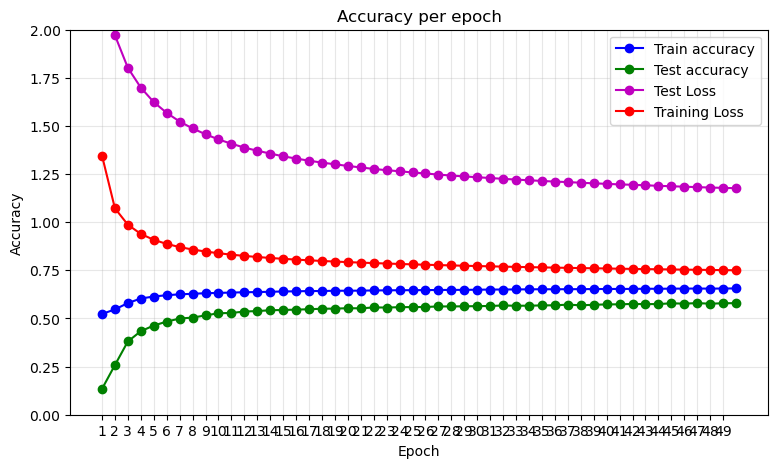

In [109]:
# Graphing our results
epochs = range(1, len(trainAcc) +1)
plt.figure(figsize=(9,5))
plt.plot(epochs, trainAcc, 'bo-', label='Train accuracy')
plt.plot(epochs, testAcc, 'go-', label='Test accuracy')
plt.plot(epochs, testLoss, 'mo-', label='Test Loss')
if trainLoss is not None:
    plt.plot(epochs, trainLoss, 'ro-', label='Training Loss')
plt.title('Accuracy per epoch')
plt.ylim(0, 2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(1,len(trainAcc)))
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [ ]:
model.save("MobileNetV2Correct.keras")

In [111]:
loss, accuracy = classifier.evaluate(xTest, yTest, batch_size=batch_size)
print("\nTest Accuracy: "+str(100*accuracy)+" \nRandom Select Odds: "+str(100*(1/(len(trashTypes))))+"% \nPercent better than Random: "+str(100*accuracy-(100*(1/(len(trashTypes))))))


177/177 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.5795 - loss: 1.1766

Test Accuracy: 57.95053243637085 
Random Select Odds: 11.11111111111111% 
Percent better than Random: 46.839421325259735


<h1>My Own Predictions</h1>

In [126]:
def predict(path):
    pathToTrashItem = path
    # Converts the image to a list of individual (blue, green, red) lists per pixels
    bgrImg = cv2.imread(pathToTrashItem)
    bgrImg = cv2.resize(bgrImg, (resizeX,resizeY),interpolation=cv2.INTER_AREA)
    rgbImg = cv2.cvtColor(bgrImg, cv2.COLOR_BGR2RGB)
    rgbImg = np.resize(rgbImg, [1, resizeX,resizeY,3]).astype('float32')
    # bgrImg = np.array(bgrImg)
    # xData = np.resize(xData, [resizeX,resizeY,3]).astype('float32')
    pred = classifier.predict(rgbImg)
    max = 0
    for i in range(len(pred[0])):
        if pred[0][i] >= max:
            # print('hi')
            max = pred[0][i]
    for i in range(len(pred[0])):
        if pred[0][i] == max:
            return(trashTypes[i])
    return(pred)


print(predict("data/myOwn/plastic.jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
metal
